# Exploratory Data Analysis (EDA)

# Demographics

In [1]:
# ignore any warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
from pathlib import Path
# load data to df
root = Path().resolve().parent
#print(root)
cleaned_data_path = root / "data"/"processed"/"bank-full-clean.csv"
#print(cleaned_data_path)
df = pd.read_csv(cleaned_data_path, sep = ",")  # specify comma as separater

# display first 10 rows of df
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


### Question 1: Which age groups are most likely to subscribe to a term deposit?

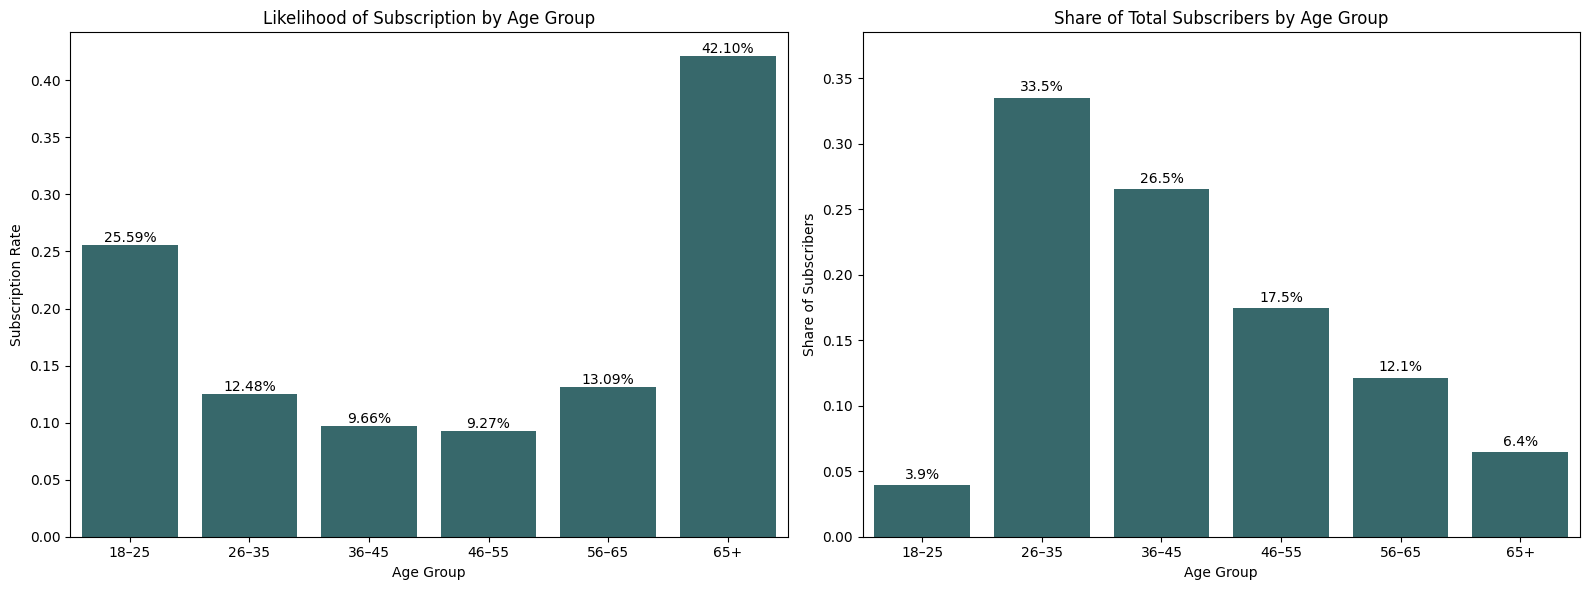

In [4]:
#----------------------------------------
# Create age bins
#----------------------------------------
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

#----------------------------------------
# Prepare data
#----------------------------------------
df['subscribed'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

subscriber_volume = (
    df[df['y'] == 'yes']['age_group']
    .value_counts(normalize=True)
    .sort_index()
)

#----------------------------------------
# Side-by-side plots
#----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Subscription Rate by Age Group ---
ax1 = axes[0]
sns.barplot(
    data=df,
    x='age_group',
    y='subscribed',
    ci=None,
    ax=ax1,
    color = '#2F6F73'
)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2%}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom')

ax1.set_title("Likelihood of Subscription by Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Subscription Rate")

# --- Plot 2: Share of All Subscribers by Age Group ---
ax2 = axes[1]
sns.barplot(
    x=subscriber_volume.index,
    y=subscriber_volume.values,
    color='#2F6F73',
    ax=ax2
)

ax2.set_title("Share of Total Subscribers by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Share of Subscribers")
ax2.set_ylim(0, subscriber_volume.max() + 0.05)

for i, v in enumerate(subscriber_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()



### #Insights
> * Age 65+ customers has highest conversion 
> * Age 26-45 is a larger group of subscribers but have low responsiveness

In [5]:
# Target Matrix with plotly to show the target segments based on subscription likelihood and subscriber volume by age group

import pandas as pd
import plotly.express as px

# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.groupby('age_group')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

# Volume table (share of all subscribers)
subscriber_counts = df[df['y'] == 'yes'].groupby('age_group').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Sample size table
sample_size = df.groupby('age_group').size().reset_index(name='sample_size')

# Merge all metrics
merged = likelihood.merge(subscriber_counts, on='age_group', how='left')
merged = merged.merge(sample_size, on='age_group', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Quadrant color map ---
quadrant_colors = {
    "Prime Target":  "#1f77b4",              # blue
    "Improvement Opportunity": "#ff7f0e",  # orange
    "Niche / Unstable": "#2ca02c",          # green
    "Low Priority": "#d62728"         # red 
}

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_data={
        "age_group": True,
        "likelihood": ":.2%",
        "volume_share": ":.2%",
        "sample_size": True,
        "subscriber_count": True,
        "quadrant": True
    },
    title="Age Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=55,
    color_discrete_map=quadrant_colors
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant labels ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2 
y_bottom = (y_min + likelihood_threshold) / 2 # not used but calculated for consistency
y_top    = (likelihood_threshold + y_max) / 2

# for improving the readability of "Improvement Opportunity" and "Low Priority" labels in the graph, we set a specific location for it
x_improve = volume_threshold + (x_max - volume_threshold) * 0.95
y_improve = y_min + (likelihood_threshold - y_min) * -1.05

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14, color= "#1f77b4"))
fig.add_annotation(x=x_improve, y=y_improve, text="Improvement Opportunity", showarrow=False, font=dict(size=14, color="#ff7f0e"))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14, color= "#2ca02c"))
fig.add_annotation(x=x_left, y=y_improve, text="Low Priority", showarrow=False, font=dict(size=14, color="#d62728"))

# --- Bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['age_group']}</b><br>"
        f"Lik: {row['likelihood']:.1%}<br>"
        f"Vol: {row['volume_share']:.1%}"
    )

    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )
    # Add information box explaining quadrants
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()


### #Insights
> *  All segments lie in "Niche/ Unstable" or "Improvement Opportunity"
> * Age by itself does not provide a reliable basis for targeting
> * The mismatch between likelihood and volume shows that age alone cannot identify high-value segment without considering other factors like job, education, or marital status

### Question 2: Are retired customers more likely to subscribe than working professionals?

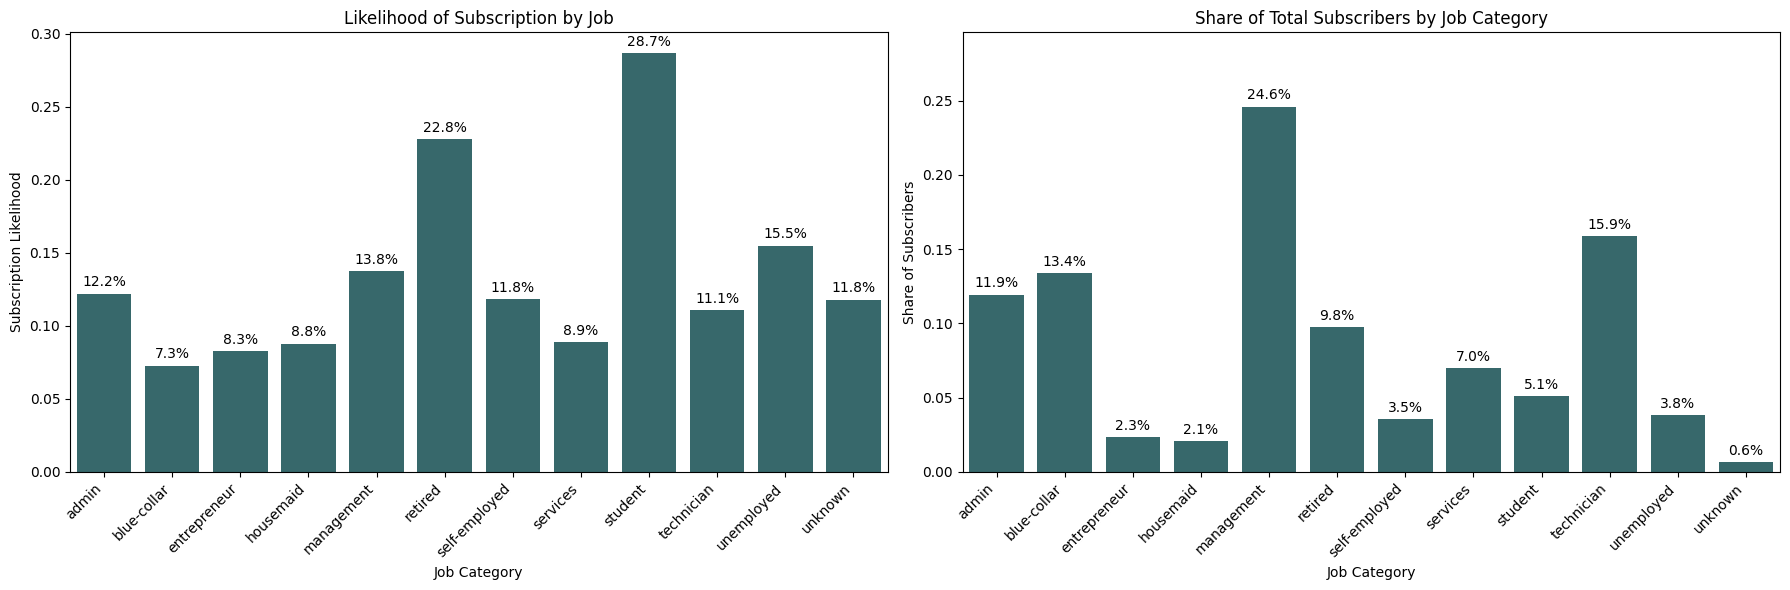

In [6]:
# Convert y to binary
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
likelihood = (
    df.groupby('job')['y_binary']
    .mean()
    #.sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
volume = (
    df[df['y'] == 'yes']['job']
    .value_counts(normalize=True)
    #.sort_index()
)

# create consistent order for both charts
job_order = sorted(df['job'].unique()) # or likelihood.index.tolist()
likelihood = likelihood.reindex(job_order)
volume = volume.reindex(job_order)

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=likelihood.index,
    y=likelihood.values,
    ax=ax1,
    color="#2F6F73"
)

ax1.set_title("Likelihood of Subscription by Job")
ax1.set_xlabel("Job Category")
ax1.set_ylabel("Subscription Likelihood")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Accurate percentage labels
for i, v in enumerate(likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center')

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=volume.index,
    y=volume.values,
    ax=ax2,
    color="#2F6F73"
)

ax2.set_title("Share of Total Subscribers by Job Category")
ax2.set_xlabel("Job Category")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()


Yes, retired customers are more likely to subscribe than working professionals

### #Insights
> - Students and Retired customers show the highest subscription likelihood, but they represent relatively small portions of the subscriber base
> - Most subscribers come from working professional groups such as management, technician, blue-collar, and admin
>   - These groups have lower likelihood but large population size, meaning even little improvements in conversion rates could generate substantial total gains

In [7]:
# Target Matrix with plotly to show the target segments based on subscription likelihood and subscriber volume by job category
import pandas as pd
import plotly.express as px

# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = (
    df.groupby('job')['y_binary']
    .mean()
    .reset_index()
    .rename(columns={'y_binary': 'likelihood'})
)

# Volume table (share of all subscribers)
subscriber_counts = (
    df[df['y'] == 'yes']
    .groupby('job')
    .size()
    .reset_index(name='subscriber_count')
)

total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Sample size table
sample_size = df.groupby('job').size().reset_index(name='sample_size')

# Merge all metrics
merged = likelihood.merge(subscriber_counts, on='job', how='left')
merged = merged.merge(sample_size, on='job', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Quadrant color map ---
quadrant_colors = {
    "Prime Target":  "#1f77b4",              # blue
    "Improvement Opportunity": "#ff7f0e",  # orange
    "Niche / Unstable": "#2ca02c",          # green
    "Low Priority": "#d62728"         # red 
}

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_data={
        "job": True,
        "likelihood": ":.2%",
        "volume_share": ":.2%",
        "sample_size": True,
        "subscriber_count": True,
        "quadrant": True
    },
    title="Job Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=55,
    color_discrete_map=quadrant_colors
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant labels ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2 
y_bottom = (y_min + likelihood_threshold) / 2 # not used but calculated for consistency
y_top    = (likelihood_threshold + y_max) / 2

# for improving the readability of "Improvement Opportunity" and "Low Priority" labels in the graph, we set a specific location for it
x_improve = volume_threshold + (x_max - volume_threshold) * 0.95
y_improve = y_min + (likelihood_threshold - y_min) * -1.05

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14, color= "#1f77b4"))
fig.add_annotation(x=x_improve, y=y_improve, text="Improvement Opportunity", showarrow=False, font=dict(size=14, color="#ff7f0e"))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14, color= "#2ca02c"))
fig.add_annotation(x=x_left, y=y_improve, text="Low Priority", showarrow=False, font=dict(size=14, color="#d62728"))

# --- Bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['job']}</b><br>"
        f"Lik: {row['likelihood']:.1%}<br>"
        f"Vol: {row['volume_share']:.1%}"
    )

    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10


    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )
    # Add information box explaining quadrants
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()


### #Insights

* The target matrix combines likelihood and volume, which helps identify where marketing spend produces the highest ROI
    > - it uses median subscription likelihood and median subscriber volume as threshold to divide job groups into 4 quadrants
    > - ensures quadrant reflects relative performance within the dataset
* Though retired clients are not the largest job group, their subscriber volume is above the median threshold used in this matrix. Combined with their high likelihood, this places them in the Prime Target quadrant

### Question 3: Does a customer's age and job jointly infuence the probability of subscription?

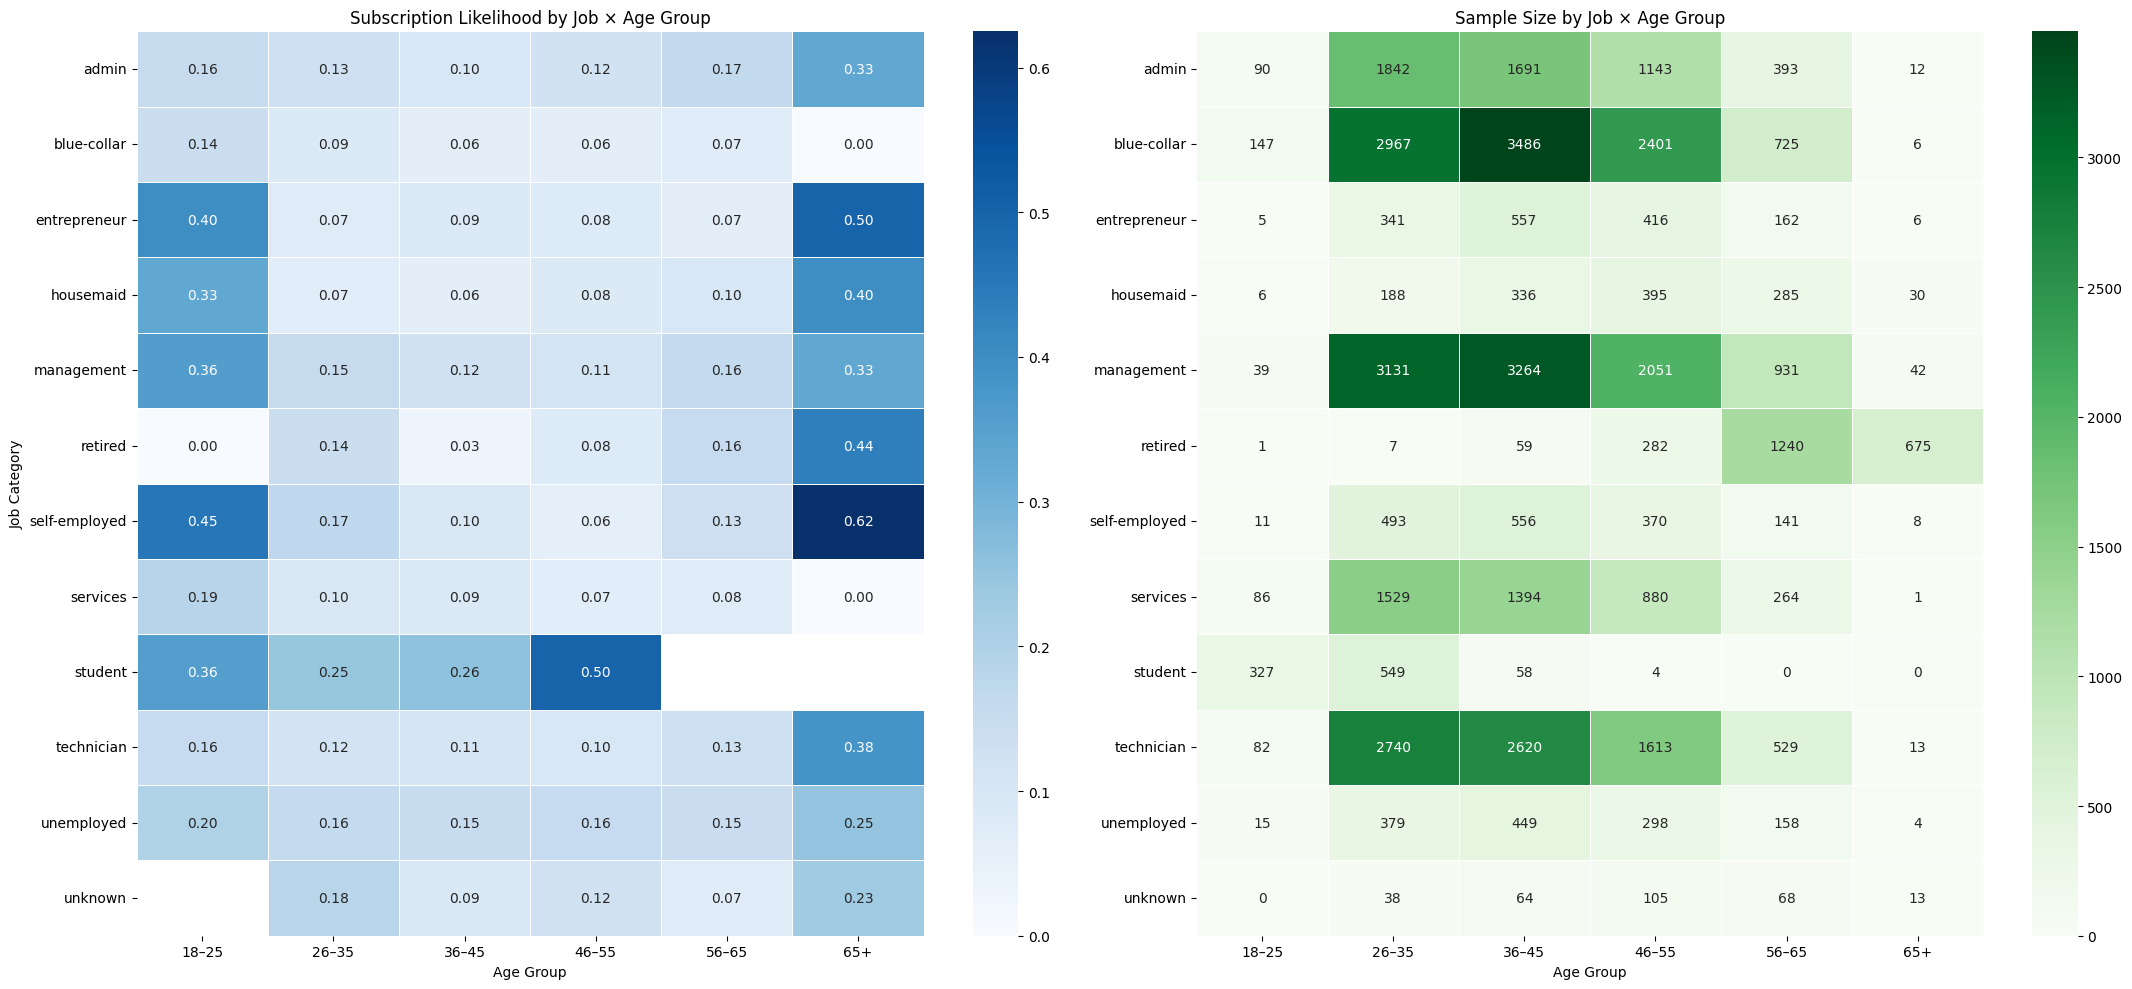

In [8]:
#-------------------------
#Dual heatmap of likelihood and volume by job and age group
#-------------------------

# --- Prepare data ---

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='mean'
)

# Sample size table
sample_size = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='count'
)

# --- Plot dual heatmaps ---

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Likelihood heatmap
sns.heatmap(
    likelihood,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    ax=axes[0]
)
axes[0].set_title("Subscription Likelihood by Job × Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Job Category")

# Sample size heatmap
sns.heatmap(
    sample_size,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=.5,
    ax=axes[1]
)
axes[1].set_title("Sample Size by Job × Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


> Summary:
- High-value segment (high likelihood + meaningful sample size):
    | Job          | Age Group      |
    |--------------|----------------|
    | Retired      | 56–65, 65+     |
    | Unemployed   | 56-65          |
    | Student      | 18–25, 26–35   |


- Improvement Opportunities (large segments but low-moderate likelihood segments):

    | Job          | Age Group                |
    |--------------|--------------------------|
    | Blue-collar  | 26–35,36–45, 46–55       |
    | Services     | 26–35,36–45, 46–55       |
    | Admin        | 26–35, 36–45             |
    | Technician   | 26–35, 36–45             |
> if conversion improved can yield largest business impact 

- High-likelihood but tiny segments (statistical noise):
    | Job          | Age Group      |
    |--------------|----------------|
    | Entrepreneur | 65+            |
    | Management   | 65+            |
    | Admin        | 65+            |
    | Technician   | 65+            |
    | Housemaid    | 65+            |
    | Student      | 46–55          |
    | Unknown      | 18–25, 65+     |
> these segments' sample size are too small to be reliable

Remarks: Stability thresholds used:
* n < 20 → statistical noise (ignore)
* 20 ≤ n < 50 → unstable but usable with caution
* n ≥ 50 → reasonably stable
* n ≥ 200 → very stable and reliable

> Conclusion:
> The heatmap shows that job and age interact strongly in shaping subscription likelihood
> - older retired customers
> - younger students
> - mid-older unemployed customers


> Working-age groups (26-35, 36-45, 45-55) such as Blue-collar, Services, Admin and Technician remain low likelihood, making them the best candidate for conversion-rate improvement

In [9]:
#-------------------------
# Interactive scatter plot of likelihood vs sample size by job and age group
#-------------------------

import plotly.express as px

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='mean'
)

# Sample size table
sample_size = df.pivot_table(
    values='y',
    index='job',
    columns='age_group',
    aggfunc='count',
    fill_value=0
)

# Melt both tables into long format
likelihood_long = likelihood.reset_index().melt(id_vars='job', var_name='age_group', value_name='likelihood')
sample_long = sample_size.reset_index().melt(id_vars='job', var_name='age_group', value_name='sample_size')

# Merge likelihood + sample size
merged = pd.merge(likelihood_long, sample_long, on=['job', 'age_group'])

# Remove rows with missing likelihood
merged = merged.dropna(subset=['likelihood'])

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
sample_threshold = merged['sample_size'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['sample_size'] >= sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['sample_size'] >= sample_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['sample_size'] < sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)


# --- Interactive scatter plot ---
fig = px.scatter(
    merged,
    x='sample_size',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_name='job',
    hover_data={
        'age_group': True,
        'sample_size': True,
        'likelihood': ':.2f',
        'quadrant': True
    },
    title="Interactive Target Matrix: Subscription Likelihood vs Sample Size (Job × Age Group)",
    labels={
        'sample_size': 'Sample Size (Segment Size)',
        'likelihood': 'Subscription Likelihood'
    },
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",              # blue
        "Improvement Opportunity": "#ff7f0e",   # orange
        "Niche / Unstable": "#2ca02c",          # green
        "Low Priority": "#d62728"               # red
    }
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=sample_threshold, line_dash="dash", line_color="gray")

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="Segment Type"
)

# --- Compute quadrant midpoints for centered labels ---
x_min, x_max = merged['sample_size'].min(), merged['sample_size'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + sample_threshold) / 2
x_right = (sample_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

# --- Add quadrant shading (background rectangles) ---
fig.add_shape(type="rect",
              x0=x_min, x1=sample_threshold,
              y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=sample_threshold, x1=x_max,
              y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=x_min, x1=sample_threshold,
              y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=sample_threshold, x1=x_max,
              y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Add centered quadrant labels ---
fig.add_annotation(
    x=x_right, y=y_top,
    text="Prime Target", #if want incorporate the quadrant explanation lable still have space for this graph, add code after: <br>High likelihood & Large sample",
    showarrow=False, font=dict(size=13)
)

fig.add_annotation(
    x=x_right, y=y_bottom,
    text="Improvement Opportunity", # add code: <br>Low likelihood & Large sample",
    showarrow=False, font=dict(size=13)
)

fig.add_annotation(
    x=x_left, y=y_top,
    text="Niche / Unstable", # add code: <br>High likelihood & Small sample",
    showarrow=False, font=dict(size=13)
)

fig.add_annotation(
    x=x_left, y=y_bottom,
    text="Low Priority", # add code: <br>Low likelihood & Small sample",
    showarrow=False, font=dict(size=13)
)

# Add information box explaining quadrants
fig.add_annotation(
    x=1.32, y=-0.15, xref="paper", yref="paper",
    text=(
    "Large sample + high likelihood → <b>Prime Targets</b><br>"
    "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
    "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
    "Small sample + low likelihood → <b>Low Priority</b>"
    ),
    showarrow=False,
    align="left",
    font=dict(size=8, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9)

fig.show()


### #Insights

> - While the heatmap shows patterns visually, the target matrix uses actual numbers and cut-off rules, it therefore picks up more (every) segments for each quadrants
> - The target matrix gives a more systematic, rule-based classification

### Question 4: Does a customer's education level impact subscription?

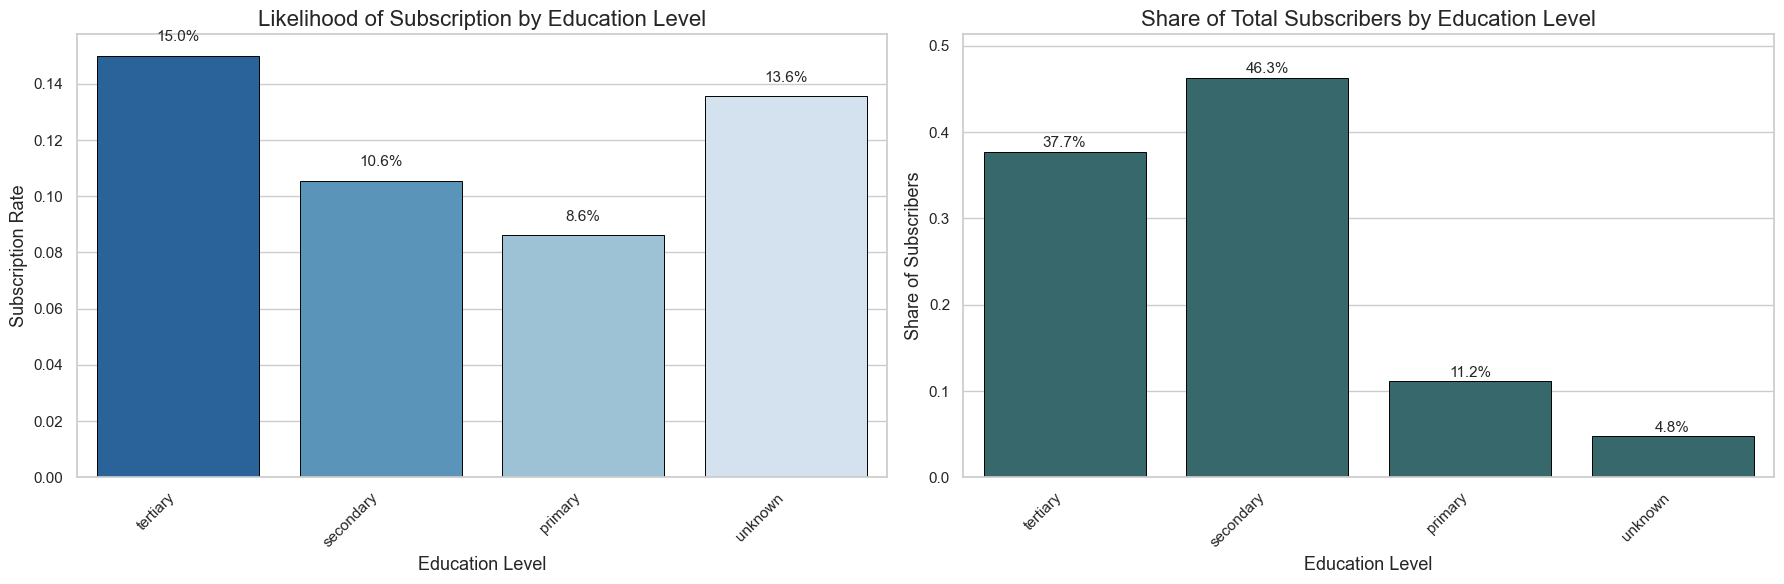

In [10]:
# Convert y to binary
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Define desired order for the charts
edu_order = ["tertiary", "secondary", "primary", "unknown"]

# Convert to ordered categorical
df['education'] = pd.Categorical(df['education'], categories=edu_order, ordered=True)


#-------------------------
# Compute likelihood
#-------------------------
edu_likelihood = (
    df.groupby('education')['y_binary']
    .mean()
    .reindex(edu_order)
    #.sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
edu_volume = (
    df[df['y'] == 'yes']['education']
    .value_counts(normalize=True)
    #.sort_index()
    .reindex(edu_order)
)


#-------------------------
# Styling
#-------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=edu_likelihood.index,
    y=edu_likelihood.values,
    ax=ax1,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.7
)

ax1.set_title("Likelihood of Subscription by Education Level")
ax1.set_xlabel("Education Level")
ax1.set_ylabel("Subscription Rate")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Percentage labels
for i, v in enumerate(edu_likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=edu_volume.index,
    y=edu_volume.values,
    ax=ax2,
    color="#2F6F73",
    edgecolor="black",
    linewidth=0.7
)

ax2.set_title("Share of Total Subscribers by Education Level")
ax2.set_xlabel("Education Level")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, edu_volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(edu_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


### #Insights

> Education level does impact subscription behaviour:
> - Higher-educated customers are more responsive and show higher likelihood of subscribing
    > - Secondary-educated customers dominate total subscriber volume

In [11]:
import pandas as pd
import plotly.express as px

# --- Prepare data ---

df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

likelihood = df.groupby('education')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

subscriber_counts = df[df['y'] == 'yes'].groupby('education').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

merged = pd.merge(likelihood, subscriber_counts, on='education', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Quadrants ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='volume_share',
    hover_data={},  # disable hover
    title="Education Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",
        "Improvement Opportunity": "#ff7f0e",
        "Niche / Unstable": "#2ca02c",
        "Low Priority": "#d62728"
    }
)

fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant shading ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Quadrant labels ---
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14))

# --- Improved bubble labels ---
for _, row in merged.iterrows():

    # Bold education name + short metrics
    label_text = (
        f"<b>{row['education']}</b><br>"
        f"Lik: {row['likelihood']:.2f} | Vol: {row['volume_share']:.2f}"
    )

    # Smart label placement: right side for left quadrants, left side for right quadrants
    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.7)",  # readable background
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        borderpad=3
    )
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()


### Question 5: How does marital status impact subscription behavior?

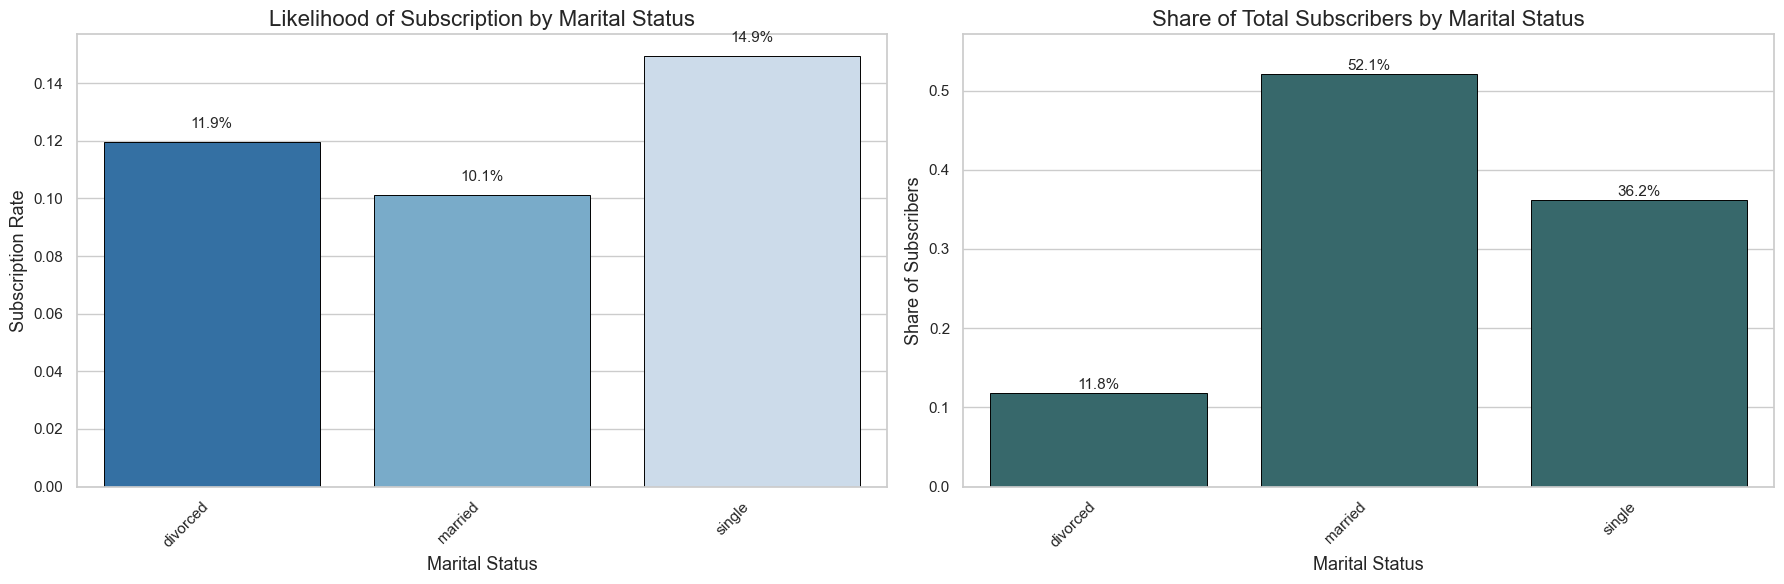

In [12]:
# Convert y to binary (if not already done)
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
marital_likelihood = (
    df.groupby('marital')['y_binary']
    .mean()
    #.sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
marital_volume = (
    df[df['y'] == 'yes']['marital']
    .value_counts(normalize=True)
    #.sort_index()
)

# create consistent order for both charts
marital_order = sorted(df['marital'].unique()) # or marital_likelihood.index.tolist
marital_likelihood = marital_likelihood.reindex(marital_order)
marital_volume = marital_volume.reindex(marital_order)


#-------------------------
# Styling
#-------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=marital_likelihood.index,
    y=marital_likelihood.values,
    ax=ax1,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.7
)

ax1.set_title("Likelihood of Subscription by Marital Status")
ax1.set_xlabel("Marital Status")
ax1.set_ylabel("Subscription Rate")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Percentage labels
for i, v in enumerate(marital_likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=marital_volume.index,
    y=marital_volume.values,
    ax=ax2,
    color="#2F6F73",
    edgecolor="black",
    linewidth=0.7
)

ax2.set_title("Share of Total Subscribers by Marital Status")
ax2.set_xlabel("Marital Status")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, marital_volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(marital_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


### #Insights

> Martial status does influence subscription behavior:
>    - Singles are more responsive
>    - but married customers drive the majority of total subscriptions because they are the largest group

In [13]:
import pandas as pd 
import plotly.express as px 
# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)
# Likelihood table
likelihood = df.groupby('marital')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

# Volume table (share of all subscribers)
subscriber_counts = df[df['y'] == 'yes'].groupby('marital').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Merge likelihood + volume
merged = pd.merge(likelihood, subscriber_counts, on='marital', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='volume_share',
    hover_data={},  # disable hover
    title="Marital Status Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",
        "Improvement Opportunity": "#ff7f0e",
        "Niche / Unstable": "#2ca02c",
        "Low Priority": "#d62728"
    }
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant shading ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Quadrant labels ---
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14))

# --- Improved bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['marital']}</b><br>"
        f"Lik: {row['likelihood']:.2f} | Vol: {row['volume_share']:.2f}"
    )

    # Smart label placement
    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )
    # Add information box explaining quadrants
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()

# Export PNG (requires Kaleido installed)
# fig.write_image("marital_target_matrix.png")


### #Insights

> Divorced customers fall on the boundary between Niche and Low Priority, meaning their subscription rate is neither high enough to be considered a strong responder nor low enough to be considered weak. Along with their subscriber volume is also moderate, so they don't show a strong strategic signal

### Additional Summary: 4-factor demographic summary chart

In [14]:
import pandas as pd
import numpy as np

# --- Prepare data ---

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Group by all 4 demographic factors
segment = df.groupby(['age_group', 'job', 'education', 'marital']).agg(
    likelihood=('y_binary', 'mean'),
    volume=('y_binary', 'sum'),
    sample_size=('y_binary', 'count')
).reset_index()

# Remove tiny segments (unstable)
segment = segment[segment['sample_size'] >= 50]

# Priority score = likelihood × log(sample size)
segment['priority_score'] = segment['likelihood'] * np.log(segment['sample_size'] + 1)

# --- Quadrant thresholds ---
likelihood_threshold = segment['likelihood'].median()
sample_threshold = segment['sample_size'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['sample_size'] >= sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['sample_size'] >= sample_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['sample_size'] < sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

segment['quadrant'] = segment.apply(classify_quadrant, axis=1)

# --- Sort segments within each quadrant ---
segment_sorted = segment.sort_values(
    by=['quadrant', 'priority_score'], ascending=[True, False]
)

# --- Create separate tables for each quadrant ---
prime_target = segment_sorted[segment_sorted['quadrant'] == "Prime Target"]
improvement = segment_sorted[segment_sorted['quadrant'] == "Improvement Opportunity"]
niche = segment_sorted[segment_sorted['quadrant'] == "Niche / Unstable"]
low_priority = segment_sorted[segment_sorted['quadrant'] == "Low Priority"]

# --- Optional: create a single combined table for export ---
summary_table = segment_sorted[[
    'quadrant', 'age_group', 'job', 'education', 'marital',
    'likelihood', 'sample_size', 'priority_score'
]]

summary_table


,quadrant,age_group,job,education,marital,likelihood,sample_size,priority_score
544,Improvement Opportunity,46–55,technician,secondary,married,0.104750,821,0.703057
148,Improvement Opportunity,26–35,admin,secondary,married,0.106489,601,0.681558
293,Improvement Opportunity,36–45,admin,secondary,single,0.104326,393,0.623487
256,Improvement Opportunity,26–35,technician,secondary,married,0.094752,686,0.618953
253,Improvement Opportunity,26–35,technician,tertiary,married,0.106164,292,0.603032
...,...,...,...,...,...,...,...,...
435,Prime Target,46–55,admin,secondary,divorced,0.121359,206,0.647175
480,Prime Target,46–55,management,tertiary,divorced,0.112540,311,0.646319
519,Prime Target,46–55,services,secondary,divorced,0.125000,128,0.607477
450,Prime Target,46–55,blue-collar,primary,divorced,0.121429,140,0.600921


In [15]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. QUADRANT BUBBLE CHART (Likelihood vs Sample Size)
# ---------------------------------------------------------

fig1 = px.scatter(
    segment,
    x="sample_size",
    y="likelihood",
    size="volume",
    color="quadrant",
    hover_data=["age_group", "job", "education", "marital", "priority_score"],
    title="Quadrant Bubble Chart: Likelihood vs Sample Size",
    labels={"sample_size": "Sample Size", "likelihood": "Subscription Likelihood"},
    size_max=40
)

fig1.update_layout(
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(showgrid=True, gridcolor="lightgrey")
)

# Add information box explaining quadrants
fig1.add_annotation(
    x=1.35, y=-0.20, xref="paper", yref="paper",
    text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
    ),
    showarrow=False,
    align="left",
    font=dict(size=12, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9
)


fig1.show()


# ---------------------------------------------------------
# 2. TREEMAP (Population Structure by 4 Demographics)
# ---------------------------------------------------------

fig2 = px.treemap(
    segment,
    path=["age_group", "job", "education", "marital"],
    values="sample_size",
    color="likelihood",
    color_continuous_scale="Blues",
    title="Treemap: Population Structure by Demographic Layers"
)

fig2.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig2.show()


# ---------------------------------------------------------
# 3. HEATMAPS (Pairwise Interactions)
# ---------------------------------------------------------

# Age × Job likelihood heatmap
heat_age_job = segment.groupby(["age_group", "job"])["likelihood"].mean().reset_index()
pivot_age_job = heat_age_job.pivot(index="age_group", columns="job", values="likelihood")

fig3 = px.imshow(
    pivot_age_job,
    color_continuous_scale="Viridis",
    title="Heatmap: Likelihood by Age Group × Job",
    labels=dict(color="Likelihood")
)

fig3.update_layout(xaxis=dict(side="top"))
fig3.show()


# Education × Job likelihood heatmap
heat_edu_job = segment.groupby(["education", "job"])["likelihood"].mean().reset_index()
pivot_edu_job = heat_edu_job.pivot(index="education", columns="job", values="likelihood")

fig4 = px.imshow(
    pivot_edu_job,
    color_continuous_scale="Viridis",
    title="Heatmap: Likelihood by Education × Job",
    labels=dict(color="Likelihood")
)

fig4.update_layout(xaxis=dict(side="top"))
fig4.show()


# ---------------------------------------------------------
# 4. TOP PRIME TARGET SEGMENTS (Ranked Bar Chart)
# ---------------------------------------------------------

top_prime = (
    segment[segment["quadrant"] == "Prime Target"]
    .sort_values("priority_score", ascending=False)
    .head(12)
)

top_prime["segment_label"] = (
    top_prime["age_group"].astype(str) + " | " +
    top_prime["job"].astype(str) + " | " +
    top_prime["education"].astype(str) + " | " +
    top_prime["marital"].astype(str)
)

fig5 = px.bar(
    top_prime,
    x="priority_score",
    y="segment_label",
    color="likelihood",
    orientation="h",
    color_continuous_scale="Greens",
    title="Top Prime Target Segments (Ranked by Priority Score)",
    labels={"priority_score": "Priority Score", "segment_label": "Segment"}
)

fig5.update_layout(yaxis=dict(categoryorder="total ascending"))

fig5.add_annotation(
    x=1, y=0, xref="paper", yref="paper",
    text=(
        "<b>Priority Score Formula</b><br>"
        "Likelihood × log(sample size + 1)<br><br>"
        "<b>Factors considered:</b><br>"
        "• Subscription likelihood<br>"
        "• Segment sample size<br>"
        "*Higher for segments with both responsive and large"
    ),
    showarrow=False,
    align="left",
    font=dict(size=12, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9
)


fig5.show()

# Remarks:
# Volume affects likelihood --> affect priority score
# Sample size affect log term --> affect priority score
# Log term <> the reason volume is included


# Financial Profile 

### Question 1:  Does higher account balance increase likelihood of subscription?

In [16]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /Users/phucnguyen/Documents/UNCLEDZE/1. Learning/1. Data/1. Data Science/1. UOfT/ds_team2_bank_marketing/notebooks


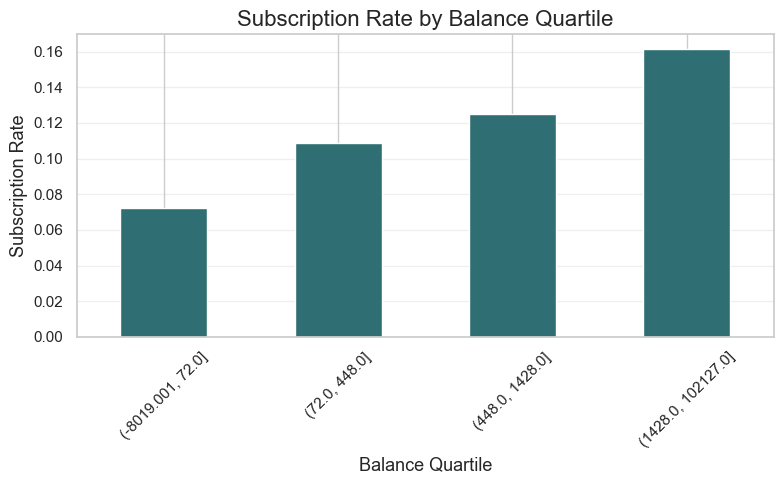

In [17]:

import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create balance quartiles
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 4) Calculate subscription rate per quartile
conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()

# 5) Plot bar chart
plt.figure(figsize=(8, 5))
conversion_by_bin.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Balance Quartile")
plt.xlabel("Balance Quartile")
plt.ylabel("Subscription Rate")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()

### #Insight
- Higher-balance customers show higher subscription rates.
- Targeting high-balance segments may improve campaign efficiency.

### Question 2: Does having a housing loan affect subscription probability? 

Subscription rate by housing loan status:
housing
no     0.167024
yes    0.077000
Name: subscribed, dtype: float64


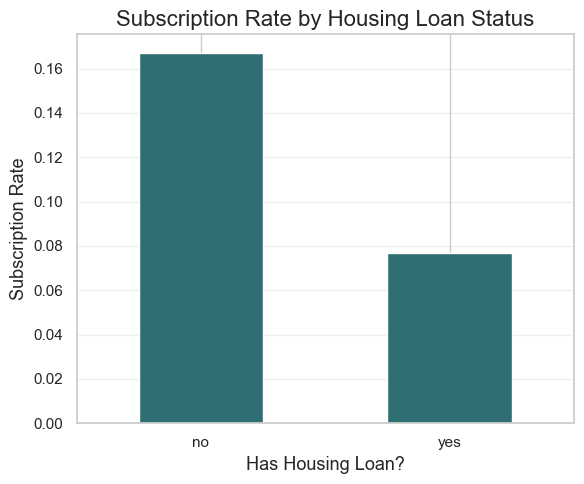

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset 
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric (1 = yes, 0 = no)
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate grouped by housing loan status
housing_conversion = df.groupby("housing")["subscribed"].mean()

print("Subscription rate by housing loan status:")
print(housing_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
housing_conversion.plot(kind="bar",color = '#2F6F73')

plt.title("Subscription Rate by Housing Loan Status")
plt.xlabel("Has Housing Loan?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insight
- Customers with housing loans have lower subscription rates.
- Housing loan status may help refine customer targeting.

### Question 3: Does having a personal loan affect subscription behavior?

Subscription rate by personal loan status:
loan
no     0.126557
yes    0.066814
Name: subscribed, dtype: float64


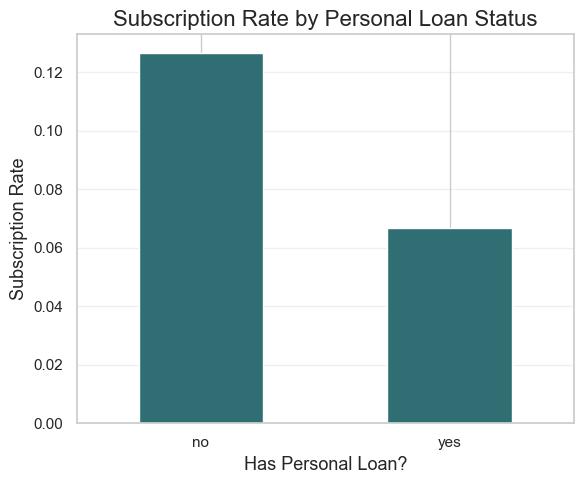

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate by personal loan status
loan_conversion = df.groupby("loan")["subscribed"].mean()

print("Subscription rate by personal loan status:")
print(loan_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
loan_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Personal Loan Status")
plt.xlabel("Has Personal Loan?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


### #Insight
- Customers with personal loans show lower subscription rates.
- Existing debt may reduce likelihood of investing in term deposits.

### Question 4: Does having credit in default reduce subscription probability?

Subscription rate by credit default status:
default
no     0.117961
yes    0.063804
Name: subscribed, dtype: float64


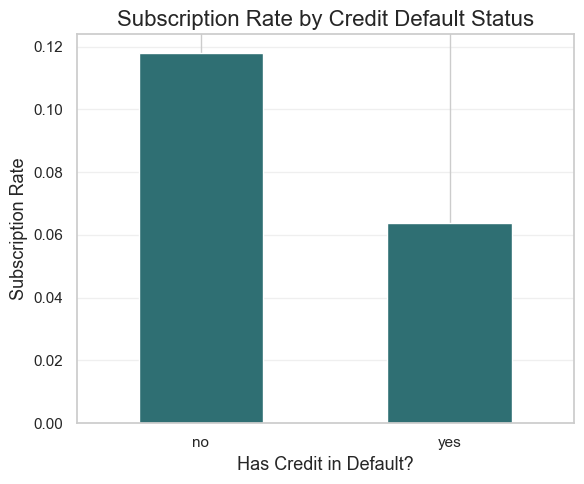

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rates by default status
default_conversion = df.groupby("default")["subscribed"].mean()

print("Subscription rate by credit default status:")
print(default_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
default_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Credit Default Status")
plt.xlabel("Has Credit in Default?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insights
- Customers with credit in default show significantly lower subscription rates.
- Credit risk status may be a strong indicator of low conversion probability.

### Question 5: Is there an interaction between balance and loan status?

Subscription rate by balance quartile and loan status:
loan                      no       yes
balance_bin                           
(-8019.001, 72.0]   0.076031  0.059571
(72.0, 448.0]       0.117660  0.066038
(448.0, 1428.0]     0.134785  0.069235
(1428.0, 102127.0]  0.170809  0.080380


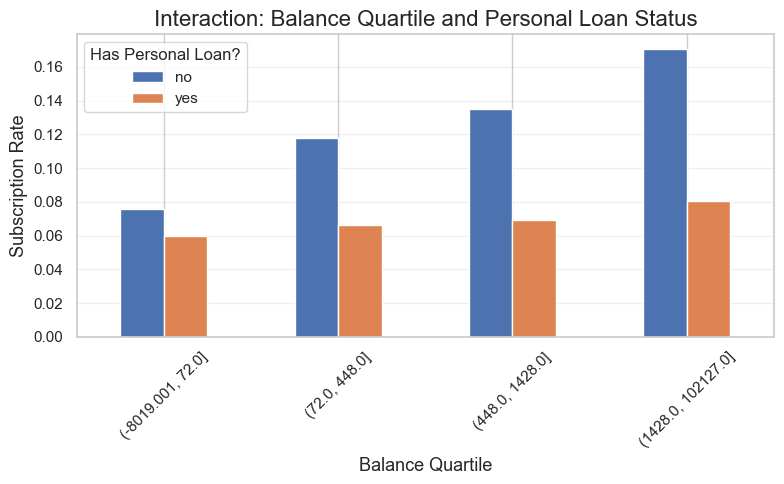

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convertt target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create balance quartiles
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 4) Group by balance quartile AND personal loan status
interaction = df.groupby(["balance_bin", "loan"])["subscribed"].mean().unstack()

print("Subscription rate by balance quartile and loan status:")
print(interaction)

# 5) Plot grouped bar chart
interaction.plot(kind="bar", figsize=(8,5))

plt.title("Interaction: Balance Quartile and Personal Loan Status")
plt.xlabel("Balance Quartile")
plt.ylabel("Subscription Rate")
plt.legend(title="Has Personal Loan?")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


plt.show()

### #Insights

If strong interaction:
- High-balance customers without loans have the highest subscription rates.
- Loan status weakens the positive effect of higher balances.

If little interaction:
- Balance increases subscription probability regardless of loan status.
- Loan status does not significantly change the balance effect.

### Question 6: Can subscription likelihood be linked to other products (e.g., loans)

Subscription rates for customers WITH each product:
                   Housing Loan (Yes)  Personal Loan (Yes)  \
Subscription Rate               0.077             0.066814   

                   Credit Default (Yes)  
Subscription Rate              0.063804  


<Figure size 700x500 with 0 Axes>

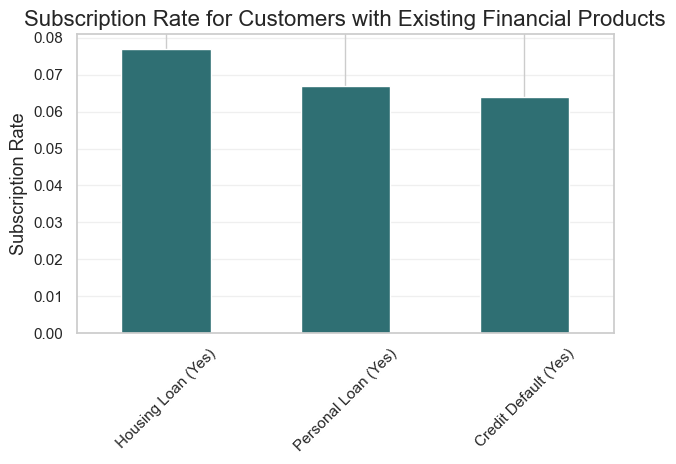

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculated subscriptiond rates for each product type
housing_rate = df.groupby("housing")["subscribed"].mean()
personal_rate = df.groupby("loan")["subscribed"].mean()
default_rate = df.groupby("default")["subscribed"].mean()

# 4) Create a comparison table (only "yes" rows for clarity)
comparison = pd.DataFrame({
    "Housing Loan (Yes)": housing_rate["yes"],
    "Personal Loan (Yes)": personal_rate["yes"],
    "Credit Default (Yes)": default_rate["yes"]
}, index=["Subscription Rate"])

print("Subscription rates for customers WITH each product:")
print(comparison)

# 5) Bar chart comparison
plt.figure(figsize=(7,5))
comparison.T.plot(kind="bar", legend=False, color = '#2F6F73')

plt.title("Subscription Rate for Customers with Existing Financial Products")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insights
- Housing loans are significantly more common than personal loans in the dataset.
- Customer debt profile is dominated by housing obligations rather than personal loans.

### Question 7: How many loans are personal vs housing loans?

Housing loan counts:
housing
yes    25130
no     20081
Name: count, dtype: int64

Personal loan counts:
loan
no     37967
yes     7244
Name: count, dtype: int64

Loan comparison:
                     Housing Loans  Personal Loans
Number of Customers          25130            7244


<Figure size 600x500 with 0 Axes>

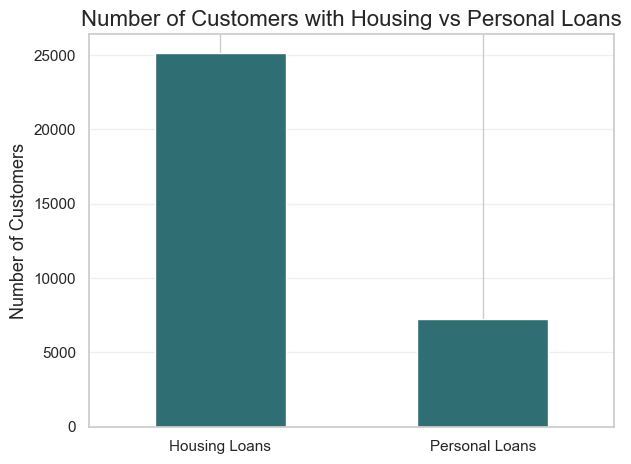

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Count housing loans
housing_counts = df["housing"].value_counts()

# 3) Count personal loans
personal_counts = df["loan"].value_counts()

print("Housing loan counts:")
print(housing_counts)

print("\nPersonal loan counts:")
print(personal_counts)

# 4) Create summary dataframe (only "yes" counts)
loan_summary = pd.DataFrame({
    "Housing Loans": housing_counts["yes"],
    "Personal Loans": personal_counts["yes"]
}, index=["Number of Customers"])

print("\nLoan comparison:")
print(loan_summary)

# 5) Bar chart comparison
plt.figure(figsize=(6,5))
loan_summary.T.plot(kind="bar", legend=False, color = '#2F6F73')

plt.title("Number of Customers with Housing vs Personal Loans")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insights
- Housing loans are significantly more common than personal loans in the dataset.
- Customer debt profile is dominated by housing obligations rather than personal loans.

### Question 8: How much higher or richer does balance need to be to meaningfully increase subscription likelihood?


Balance Percentiles:
0.25      72.0
0.50     448.0
0.75    1428.0
Name: balance, dtype: float64

Subscription rate by balance quartile:
balance_bin
(-8019.001, 72.0]     0.072369
(72.0, 448.0]         0.108936
(448.0, 1428.0]       0.125155
(1428.0, 102127.0]    0.161547
Name: subscribed, dtype: float64

Top 25% balance threshold (75th percentile): € 1428.0


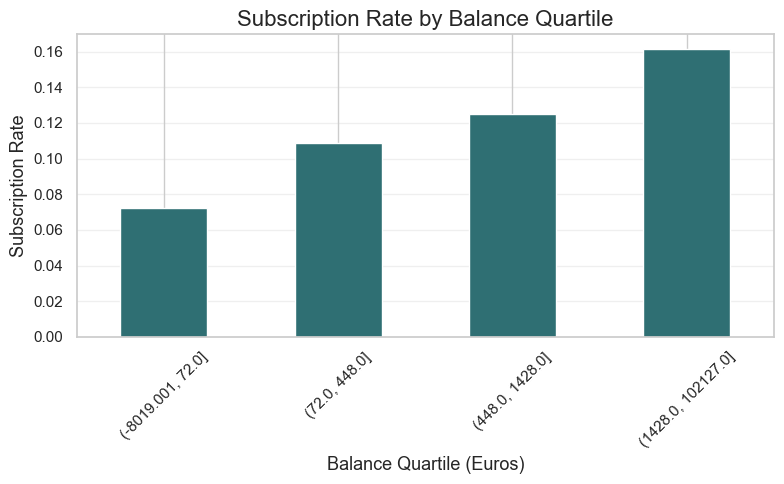

In [24]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert target to numeric (1 = yes, 0 = no)
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate balance percentiles (these help us define what "high balance" means)
percentiles = df["balance"].quantile([0.25, 0.5, 0.75])

print("Balance Percentiles:")
print(percentiles)

# 4) Create balance quartiles (4 equal-sized groups)
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 5) Calculate subscription rate per quartile
conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()

print("\nSubscription rate by balance quartile:")
print(conversion_by_bin)

# 6) Identify threshold for top quartile
top_threshold = percentiles.loc[0.75]
print("\nTop 25% balance threshold (75th percentile): €", round(top_threshold, 2))

# 7) Bar chart comparison

plt.figure(figsize=(8, 5))
conversion_by_bin.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Balance Quartile")
plt.xlabel("Balance Quartile (Euros)")
plt.ylabel("Subscription Rate")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### #Insights
- High income is considered $1,428

# PREVIOUS CAMPAIGN EFFECTIVENESS


### Question 1: Are customers with previous successful campaigns more likely to subscribe again?

Subscription rate comparison:
previous_success
No Previous Success    0.098650
Previous Success       0.647253
Name: subscribed, dtype: float64


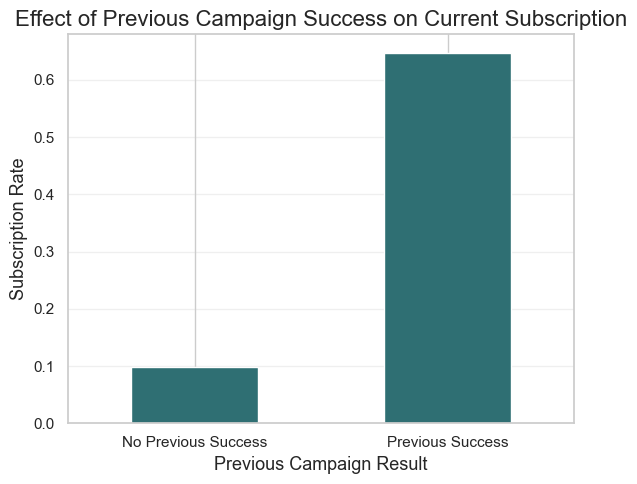

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create a new column to isolate previous success vs others
df["previous_success"] = df["poutcome"].apply(
    lambda x: "Previous Success" if x == "success" else "No Previous Success"
)

# 4) Calculate subscription rate
success_conversion = df.groupby("previous_success")["subscribed"].mean()

print("Subscription rate comparison:")
print(success_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
success_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Effect of Previous Campaign Success on Current Subscription")
plt.xlabel("Previous Campaign Result")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# plt.savefig("png_previouscampaign/02_previous_success_vs_subscription.png", dpi=300)

plt.show()

### Key Variables: poutcome, y, subscribed

### #Insights 
- Customers who previously subscribed are significantly more likely to subscribe again.
- Prior campaign success is one of the strongest predictors of current conversion.

### Question 2: Are customers who previously declined campaign offers more likely to subscribe in a future campaign?

Subscription rate comparison:
previous_failure
No Previous Failure    0.115877
Previous Failure       0.126097
Name: subscribed, dtype: float64


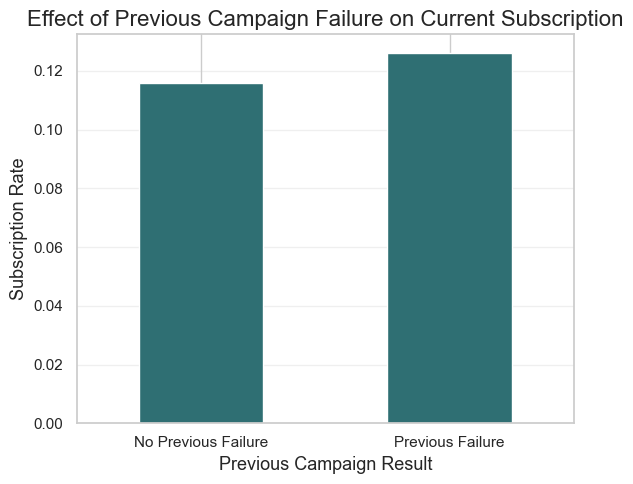

In [26]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create a new column to isolate previous failure vs others
df["previous_failure"] = df["poutcome"].apply(
    lambda x: "Previous Failure" if x == "failure" else "No Previous Failure"
)

# 4) Calculate subscription rate
failure_conversion = df.groupby("previous_failure")["subscribed"].mean()

print("Subscription rate comparison:")
print(failure_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
failure_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Effect of Previous Campaign Failure on Current Subscription")
plt.xlabel("Previous Campaign Result")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Key Variables: poutcome, y, subscribed

### #Insights 
- Customers who previously failed to subscribe show lower conversion rates in the current campaign.
- Repeatedly targeting previously unsuccessful customers may lead to diminishing returns.

### Question 3: Does time since last contact (pdays) influence success probability?

Subscription rate by pdays group:
pdays_group
0–30 Days          0.148936
31–90 Days         0.420755
90+ Days           0.219392
Never Contacted    0.091573
Name: subscribed, dtype: float64


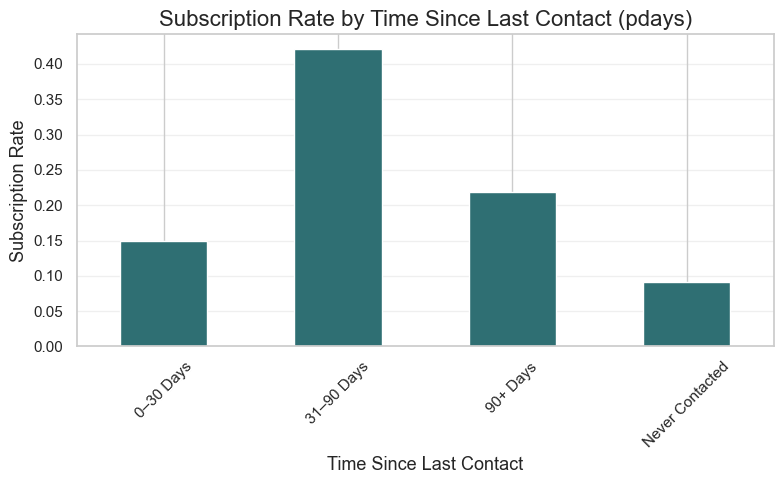

In [27]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create pdays categories
def categorize_pdays(x):
    if x == -1:
        return "Never Contacted"
    elif x <= 30:
        return "0–30 Days"
    elif x <= 90:
        return "31–90 Days"
    else:
        return "90+ Days"

df["pdays_group"] = df["pdays"].apply(categorize_pdays)

# 4) Calculate subscription rate by pdays group
pdays_conversion = df.groupby("pdays_group")["subscribed"].mean()

print("Subscription rate by pdays group:")
print(pdays_conversion)

# 5) Plot bar chart
plt.figure(figsize=(8,5))
pdays_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Time Since Last Contact (pdays)")
plt.xlabel("Time Since Last Contact")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Key Variables: pdays, y, subscribed

### #Insights 
- Customers contacted more recently show higher subscription rates.
- Subscription likelihood decreases as time since last contact increases.
- Recency appears to be an important driver of campaign effectiveness.

### Question 4: Are existing customers more likely to subscribe than new ones?

Subscription rate by customer type:
customer_type
Existing Customer    0.230713
New Customer         0.091573
Name: subscribed, dtype: float64


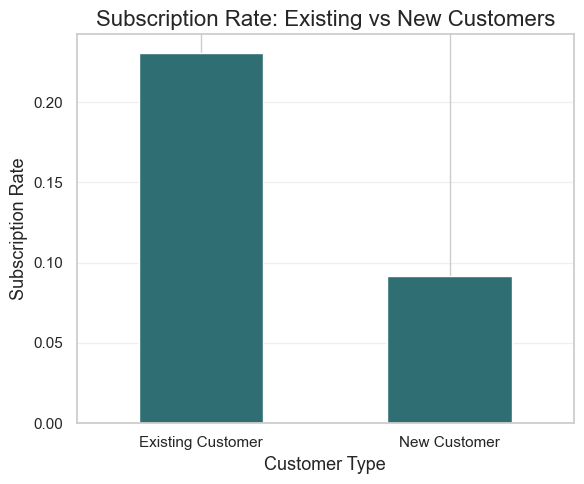

In [28]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create customer type column
df["customer_type"] = df["pdays"].apply(
    lambda x: "Existing Customer" if x != -1 else "New Customer"
)

# 4) Calculate subscription rate
customer_conversion = df.groupby("customer_type")["subscribed"].mean()

print("Subscription rate by customer type:")
print(customer_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
customer_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate: Existing vs New Customers")
plt.xlabel("Customer Type")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


plt.show()

### Key Variables: pdays, y, subscribed

### #Insights 
- Existing customers generally show higher subscription rates than new customers.
- Prior engagement increases likelihood of conversion.
- Retargeting known customers may be more efficient than focusing only on new prospects.

### Question 5: How does the subscription rate vary across months?

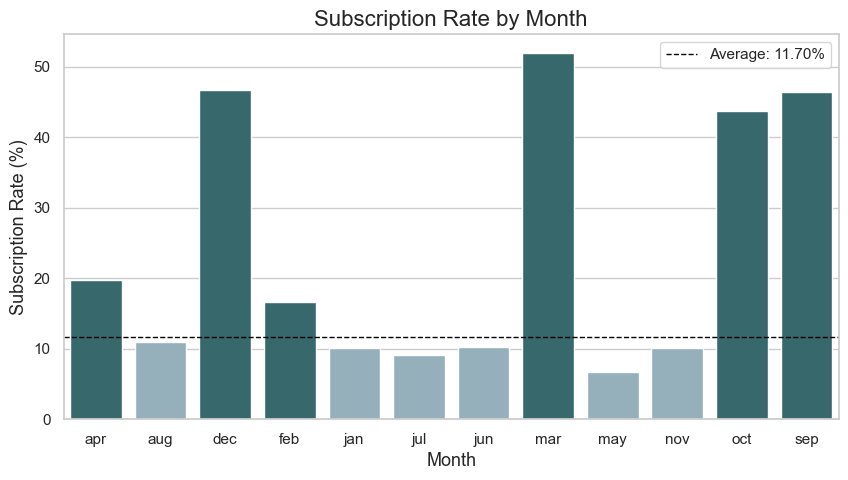

In [29]:
eda_df = df.copy()
eda_df['only_yes'] = (eda_df['y'] == 'yes').astype(int)
month_success = eda_df.groupby('month')['only_yes'].mean().mul(100).reset_index()
overall_avg = eda_df['only_yes'].mean() * 100

plt.figure(figsize=(10,5))
month_success['color'] = month_success['only_yes'].apply(lambda x: '#2F6F73' if x >= overall_avg else '#8FB3C1')
sns.barplot(x='month', y='only_yes', data=month_success, palette=month_success['color'].tolist())
plt.axhline(overall_avg, color='black', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.title('Subscription Rate by Month')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Month')
plt.legend()
plt.show()

### #Insights 
- Subscription rates are higher in specific months. March stands out with the highest subscription rate (over 50%). September, October, and December also have subscription rates well above the average line.

### Question 6: How does call duration relate to subscription? 

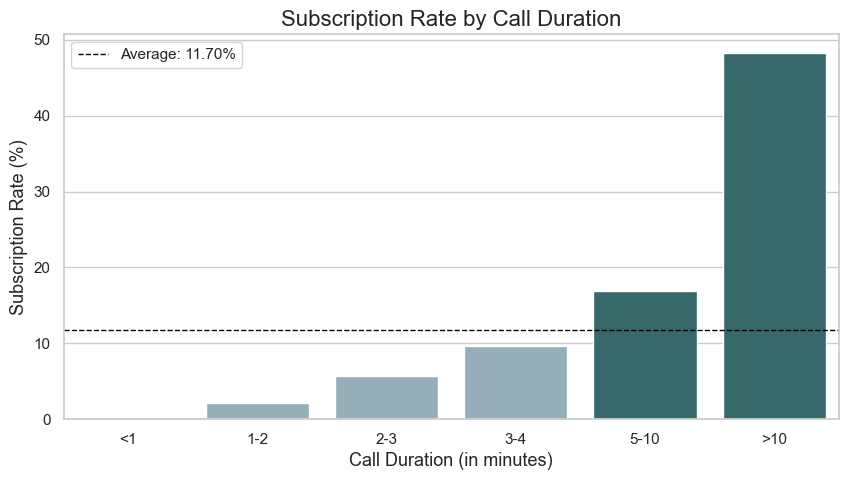

In [30]:
# define bins (in minutes)
bins = [0, 1, 2, 3, 4, 10, eda_df['duration'].max()+1]
labels = ['<1','1-2','2-3','3-4','5-10','>10']
# create bins
eda_df['duration_bin'] = pd.cut(eda_df['duration']/60, bins=bins, labels=labels, right=False)

duration_success = eda_df.groupby('duration_bin')['only_yes'].mean().mul(100).reset_index()

plt.figure(figsize=(10,5))
duration_success['color'] = duration_success['only_yes'].apply(lambda x: '#2F6F73' if x >= overall_avg else '#8FB3C1')
sns.barplot(x='duration_bin', y='only_yes', data=duration_success, palette=duration_success['color'].tolist())
plt.axhline(overall_avg, color='black', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Call Duration (in minutes)')
plt.title('Subscription Rate by Call Duration')
plt.legend()
plt.show()

### #Insights  
- Longer calls lead to more subscriptions. Spending more time talking helps convince customers, while very short calls rarely work. To get better results, calls should last at least 5 minutes.

### Question 7: Does subscription probability decrease after too many calls?

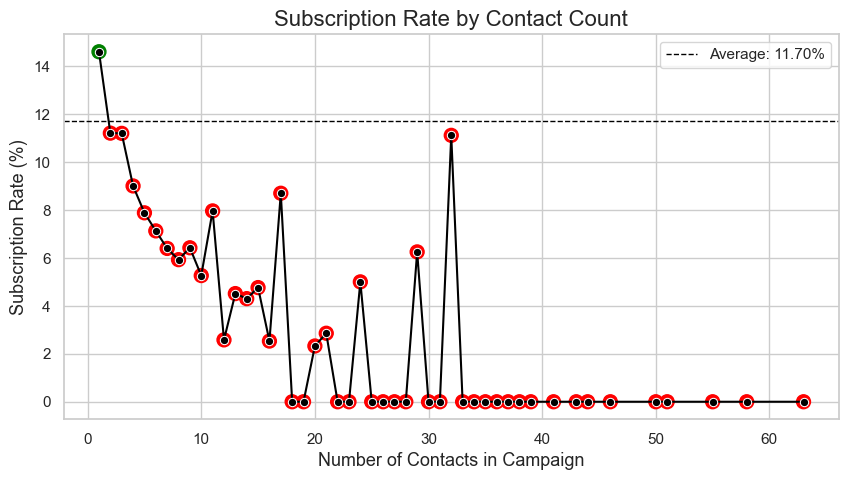

In [31]:
contact_success = eda_df.groupby('campaign')['only_yes'].mean().mul(100).reset_index()

contact_success['color'] = contact_success['only_yes'].apply(lambda x: 'green' if x >= overall_avg else 'red')
plt.figure(figsize=(10,5))
sns.lineplot(data=contact_success, x='campaign', y='only_yes', marker='o', color='black')
plt.scatter(contact_success['campaign'], contact_success['only_yes'], color=contact_success['color'], s=100)
plt.axhline(overall_avg, color='black', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.title('Subscription Rate by Contact Count')
plt.xlabel('Number of Contacts in Campaign')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### #Insights 
- We can see a strong inverse relationship between contact frequency and subscription rate. Clients contacted only once converted at ~14.8%, while rates drop sharply and consistently as contact count increases, with a few spikes, but these remain below the average subscription rate.

### Question 8: Are customers with previous successful campaigns significantly more likely to subscribe again?

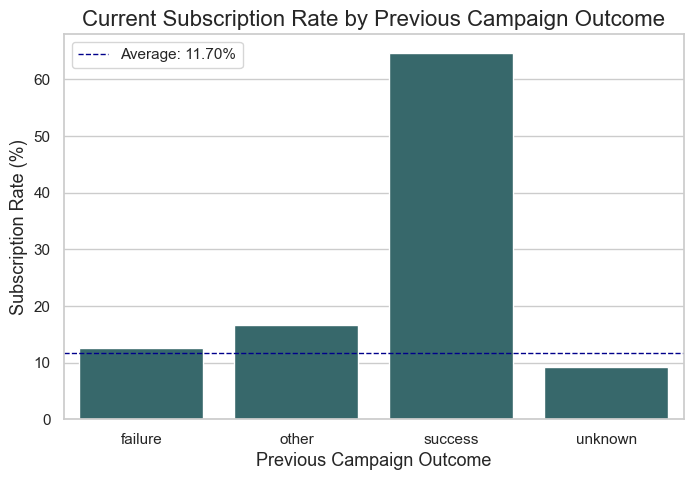

In [32]:
prev_outcome = eda_df.groupby('poutcome')['only_yes'].mean().mul(100).reset_index()

plt.figure(figsize=(8,5))
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
sns.barplot(data=prev_outcome, x='poutcome', y='only_yes', color = '#2F6F73')
plt.title('Current Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### #Insights 
- Customers with previous campaign success have significantly higher subscription rates.
- Customers with previous campaign failure are much less likely to convert.
- Retargeting previously successful customers appears highly effective.

### Question 9: Does how we contact the customer matter?

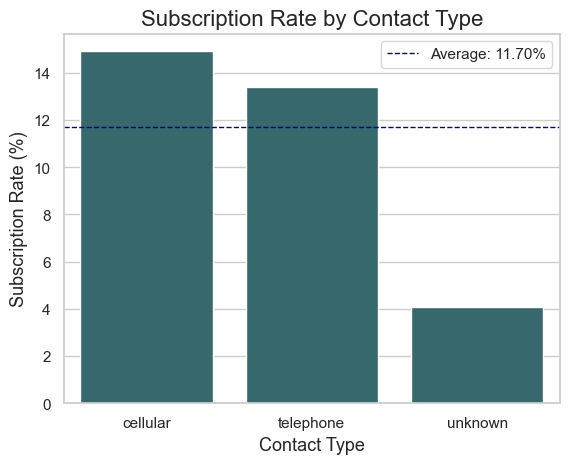

In [33]:
contact_type_success = eda_df.groupby('contact')['only_yes'].mean().mul(100).reset_index()

sns.barplot(data=contact_type_success, x="contact", y="only_yes", color = '#2F6F73')
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')

plt.title('Subscription Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### #Insights
- Both contact methods are effective, with the cellular method having a slight, but not significant, advantage.

# Customer Segmentation

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [35]:
# load data to df
ROOT = Path().resolve().parents[0]
DATA_PATH = ROOT / "data" / "processed" / "bank-full-cleaned-processed-engineered.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_bucket,age_bucket
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,high,55-65
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,low,35-45
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,low,25-35
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,high,45-55
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,low,25-35


The variable `duration` represents the length of the last contact with a customer (in seconds). Although it is one of the strongest predictors of subscription in the dataset, it must be excluded from segmentation and prediction models intended for `business targeting`, because it is not available at the time the bank decides which customers to target. Since call duration is only observed after a customer has been contacted, including it would introduce d`ata leakage`, allowing the model to use information that would not exist in a real targeting scenario. Interested customers tend to stay on the phone longer-it does not help identify customers `before contact occurs`, which is the objective of this segmentation and prediction analysis.

In [36]:
# Remove duration
df = df.drop(columns=['duration'])

## Segmentation approach

To avoid misleading results from tiny groups, we apply a **minimum segment size** filter (e.g., at least 200 customers per segment). The final outputs focus on segments that are both **large enough to be reliable** and **meaningfully above/below the baseline** (via lift).


In [37]:
# Baseline conversion rate
baseline = df["y"].mean()
print("Baseline conversion rate:", round(baseline, 4))


Baseline conversion rate: 0.117


Calculates the baseline conversion rate to establish a reference for evaluating all customer segments and predictive results. Before identifying high or low-performing groups, we need to know the overall probability of subscription in the dataset so we can judge whether a segment truly performs better or worse than average. This baseline will be used throughout the analysis to compute lift and to interpret whether a targeting strategy represents a meaningful improvement over contacting customers at random

In [38]:
# Segmentation thresholds
MIN_N = 200          # minimum segment size to be included
TARGET_LIFT = 1.50   # target threshold
AVOID_LIFT = 0.70    # avoid threshold


For the segmentation analysis, customers are grouped into segments based on selected variables (e.g., age bucket, loan status, or balance bucket), and the conversion rate is calculated for each segment. These segment conversion rates are compared to the overall baseline conversion rate using lift, defined as

$$
\text{Lift} = \frac{\text{Segment Conversion Rate}}{\text{Baseline Conversion Rate}}
$$

where:

$$
\text{Segment Conversion Rate} = \frac{\text{Number of Subscriptions in Segment}}{\text{Number of Customers in Segment}}
$$

$$
\text{Baseline Conversion Rate} = \frac{\text{Total Number of Subscriptions}}{\text{Total Number of Customers}}
$$
	​


Lift measures how much better or worse a segment performs relative to the average customer. To ensure reliable results, segment performance is evaluated separately on training and test datasets, and only segments with sufficient sample size and consistent lift are considered stable.

Consistent lift example: A segment such as customers aged 55–65 with no loan might have a conversion rate of 22% in the training set and 21% in the test set, resulting in similar lift values in both datasets. Because the segment performs consistently, it is considered stable and reliable for targeting. In contrast, if a segment shows 20% conversion in training but only 8% in test, the large difference suggests the segment is unstable and likely influenced by random variation.

Sample size example: Segments with very small sample sizes are removed because their conversion rates are unreliable. For example, if a segment contains only 12 customers in training and 5 in test, even a few subscriptions could produce a very high conversion rate (e.g., 40%), but this result could easily occur by chance. By requiring each segment to have at least a minimum number of observations (e.g., 30 customers in both training and test sets), the analysis focuses only on segments large enough to produce stable and trustworthy estimates.

In [39]:
def evaluate_segments_full(data, group_vars, baseline, min_size=200):
    """Compute segment size, conversion, lift, and % customers on the full dataset.

    Parameters
    ----------
    data : pandas.DataFrame
        Full dataset containing the target column 'y'.
    group_vars : list[str]
        Variables used to define segments (e.g., ['age_bucket', 'loan']).
    baseline : float
        Baseline conversion rate on the full dataset.
    min_size : int
        Minimum number of observations required for a segment to be included.

    Returns
    -------
    pandas.DataFrame
        Segment table with: n, conversion, lift, pct_customers.
    """
    seg = (
        data.groupby(group_vars, observed=True)
        .agg(
            n=("y", "size"),
            conv=("y", "mean")
        )
        .reset_index()
    )

    seg["lift"] = seg["conv"] / baseline
    seg["pct_customers"] = seg["n"] / len(data) * 100

    # Minimum-size filter for reliability
    seg = seg[seg["n"] >= min_size].copy()

    return seg.sort_values("lift", ascending=False)


In [40]:
# Define list of variables
profile_vars = [
    'age_bucket',
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'balance_bucket'
]

## Segmentation (One-Way)

Start with one-way segments to understand which *single* variables are most associated with subscription (and to set expectations before looking for interactions).

In [41]:
single_tables = []

for var in profile_vars:
    seg = evaluate_segments_full(df, [var], baseline, min_size=MIN_N)

    seg["variable"] = var
    seg = seg.rename(columns={var: "segment_value"})

    seg = seg[[
        "variable",
        "segment_value",
        "n",
        "pct_customers",
        "conv",
        "lift"
    ]]

    single_tables.append(seg)

single_results_clean = pd.concat(single_tables, ignore_index=True)

single_results_clean.sort_values("lift", ascending=False).head(15)


,variable,segment_value,n,pct_customers,conv,lift
0,age_bucket,65+,751,1.661100,0.426099,3.642341
6,job,student,938,2.074716,0.286780,2.451433
1,age_bucket,18-25,1324,2.928491,0.236405,2.020817
7,job,retired,2264,5.007631,0.227915,1.948246
27,housing,no,20081,44.416182,0.167024,1.427737
31,balance_bucket,high,13814,30.554511,0.155350,1.327947
8,job,unemployed,1303,2.882042,0.155027,1.325188
21,education,tertiary,13301,29.419831,0.150064,1.282764
18,marital,single,12790,28.289576,0.149492,1.277874
2,age_bucket,55-65,4149,9.176970,0.141239,1.207326


## Two-Way Combinations

Two-way combinations help identify *interactions* (e.g., age group matters more when loan status is considered). We stop at two-way because 3+ way combinations quickly become sparse, unstable, and hard to operationalize.

In [42]:
# Updated two-way tests (bucketed variables for stability + interpretability)
two_way_tests = [
    ("age_bucket", "loan"),
    ("age_bucket", "housing"),
    ("loan", "housing"),

    ("balance_bucket", "loan"),
    ("balance_bucket", "housing"),
    ("balance_bucket", "age_bucket"),

    ("job", "loan"),
    ("job", "housing"),
    ("marital", "loan"),
    ("marital", "housing"),

    ("education", "job"),
    ("education", "loan"),

    ("age_bucket", "marital"),
    ("age_bucket", "job"),

    ("balance_bucket", "job"),
    ("balance_bucket", "marital"),
]

In [43]:
two_way_tables = []

for a, b in two_way_tests:
    seg = evaluate_segments_full(df, [a, b], baseline, min_size=MIN_N)

    # Create readable "values" label (e.g., 'student & no')
    seg["segment"] = seg[a].astype(str) + " & " + seg[b].astype(str)
    seg["segment_type"] = f"{a} x {b}"

    seg = seg[[
        "segment_type",
        "segment",
        "n",
        "pct_customers",
        "conv",
        "lift"
    ]]

    two_way_tables.append(seg)

two_way_results_clean = pd.concat(two_way_tables, ignore_index=True)
two_way_results_clean.sort_values("lift", ascending=False).head(20)


,segment_type,segment,n,pct_customers,conv,lift
41,balance_bucket x age_bucket,high & 65+,426,0.942249,0.446009,3.812541
166,age_bucket x job,65+ & retired,635,1.404525,0.444094,3.796172
0,age_bucket x loan,65+ & no,747,1.652253,0.425703,3.638958
10,age_bucket x housing,65+ & no,730,1.614651,0.417808,3.571474
153,age_bucket x marital,65+ & married,575,1.271814,0.417391,3.567910
11,age_bucket x housing,18-25 & no,627,1.386831,0.387560,3.312907
81,job x housing,student & no,689,1.523965,0.358491,3.064420
167,age_bucket x job,18-25 & student,398,0.880317,0.354271,3.028354
204,balance_bucket x job,high & student,309,0.683462,0.313916,2.683390
116,education x job,secondary & student,508,1.123620,0.297244,2.540878


### Decision tables: Target vs Avoid

To make the output decision-friendly, define simple rules:
- **Target**: high lift, stable, and big enough to matter
- **Avoid**: low lift, stable, and big enough to matter

(Thresholds below are adjustable, but keep them explicit.)

In [44]:
# Decision tables: Target vs Avoid
targets = (
    two_way_results_clean[
        (two_way_results_clean["lift"] >= TARGET_LIFT)
    ]
    .sort_values(["lift", "pct_customers"], ascending=[False, False])
)

avoids = (
    two_way_results_clean[
        (two_way_results_clean["lift"] <= AVOID_LIFT)
    ]
    .sort_values(["lift", "pct_customers"], ascending=[True, False])
)

targets.head(15), avoids.head(15)


(                    segment_type              segment    n  pct_customers  \
 41   balance_bucket x age_bucket           high & 65+  426       0.942249   
 166             age_bucket x job        65+ & retired  635       1.404525   
 0              age_bucket x loan             65+ & no  747       1.652253   
 10          age_bucket x housing             65+ & no  730       1.614651   
 153         age_bucket x marital        65+ & married  575       1.271814   
 11          age_bucket x housing           18-25 & no  627       1.386831   
 81                 job x housing         student & no  689       1.523965   
 167             age_bucket x job      18-25 & student  398       0.880317   
 204         balance_bucket x job       high & student  309       0.683462   
 116              education x job  secondary & student  508       1.123620   
 205         balance_bucket x job       high & retired  967       2.138860   
 61                    job x loan         student & no  926     

## Target Map

A plot is helpful as *supporting evidence*, but the main interpretation should come from the decision tables above. Here we use an interactive chart with hover tooltips and only label a few top segments.

In [45]:
# Plotly setup: if notebook rendering fails, fall back to opening in browser
import plotly.io as pio

try:
    import nbformat  # noqa: F401
    # If nbformat exists, the default should work
except Exception:
    pio.renderers.default = "browser"

In [46]:
import numpy as np
import plotly.express as px

# Prepare plotting dataframe
plot_df = two_way_results_clean.copy()

plot_df["class"] = "Neutral"
plot_df.loc[plot_df["lift"] >= TARGET_LIFT, "class"] = "Target"
plot_df.loc[plot_df["lift"] <= AVOID_LIFT, "class"] = "Avoid"

# Bubble size scaling so big segments don't dominate
plot_df["size_sqrt"] = np.sqrt(plot_df["n"])

fig = px.scatter(
    plot_df,
    x="pct_customers",
    y="lift",
    size="size_sqrt",
    color="class",
    title="Decision Map (Two-way Segments): Lift vs % of Customers"
)

# Reference lines
fig.add_hline(y=1.0, line_dash="dot")
fig.add_hline(y=TARGET_LIFT, line_dash="dash")
fig.add_hline(y=AVOID_LIFT, line_dash="dash")

# Custom hover: ONLY show segment definition + class (numbers are in supplemental tables)
fig.update_traces(
    customdata=plot_df[["segment_type", "segment", "class"]].to_numpy(),
    hovertemplate=(
        "Segment: %{customdata[0]}<br>"
        "Values: %{customdata[1]}<br>"
        "Class: %{customdata[2]}"
        "<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="% of customers (full dataset)",
    yaxis_title="Lift vs baseline (full dataset)",
    legend_title_text="Segment class",
    height=650
)

fig.show()


### Supplemental tables

These tables are for decisions.

In [47]:
# Supplemental decision table (top 10 targets + top 10 avoids)
targets_display = targets.copy()
targets_display["class"] = "Target"

avoids_display = avoids.copy()
avoids_display["class"] = "Avoid"

decision_table = pd.concat([
    targets_display.head(10),
    avoids_display.head(10)
], ignore_index=True)

decision_table


,segment_type,segment,n,pct_customers,conv,lift,class
0,balance_bucket x age_bucket,high & 65+,426,0.942249,0.446009,3.812541,Target
1,age_bucket x job,65+ & retired,635,1.404525,0.444094,3.796172,Target
2,age_bucket x loan,65+ & no,747,1.652253,0.425703,3.638958,Target
3,age_bucket x housing,65+ & no,730,1.614651,0.417808,3.571474,Target
4,age_bucket x marital,65+ & married,575,1.271814,0.417391,3.567910,Target
5,age_bucket x housing,18-25 & no,627,1.386831,0.387560,3.312907,Target
6,job x housing,student & no,689,1.523965,0.358491,3.064420,Target
7,age_bucket x job,18-25 & student,398,0.880317,0.354271,3.028354,Target
8,balance_bucket x job,high & student,309,0.683462,0.313916,2.683390,Target
9,education x job,secondary & student,508,1.123620,0.297244,2.540878,Target


In [48]:
import plotly.graph_objects as go

baseline = df["y"].mean()

fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=[
                    "Segment type",
                    "Segment values",
                    "Class",
                    "% customers",
                    "Segment conv.",
                    "Lift"
                ],
                align="left"
            ),
            cells=dict(
                values=[
                    decision_table["segment_type"],
                    decision_table["segment"],
                    decision_table["class"],
                    decision_table["pct_customers"].round(2),
                    decision_table["conv"].round(3),
                    decision_table["lift"].round(2)
                ],
                align="left"
            )
        )
    ]
)

# fig.update_layout(
#     title="Decision Table: Target and Avoid Segments",
#     height=500
# )

fig.update_layout(
    title="Decision Table: Target and Avoid Segments",
    margin=dict(t=120)
)

# Baseline annotation (appears once above table)
fig.add_annotation(
    text=(
        f"Baseline conversion rate = {baseline:.3f}  |  "
        "% customers = segment size ÷ total customers  |  "
        "Lift = segment conversion ÷ baseline conversion"
    ),
    x=0,
    y=1.12,
    xref="paper",
    yref="paper",
    showarrow=False,
    align="left"
)

fig.show()

In [49]:
# Visual "table": ranked bar charts

top_targets_vis = targets.head(12).copy()
top_targets_vis["label"] = top_targets_vis["segment_type"] + " | " + top_targets_vis["segment"]

fig = px.bar(
    top_targets_vis.sort_values("lift"),
    x="lift",
    y="label",
    orientation="h",
    title="Top Target Segments (ranked by lift)",
)

# Baseline annotation (appears once above table)
fig.add_annotation(
    text=(
        f"Baseline conversion rate = {baseline:.3f}  |  "
        "Lift = segment conversion ÷ baseline conversion"
    ),
    x=0,
    y=1.12,
    xref="paper",
    yref="paper",
    showarrow=False,
    align="left"
)
fig.update_traces(marker_color="#2F6F73")
fig.add_vline(x=1.0, line_dash="dot")
fig.update_layout(xaxis_title="Lift vs baseline", yaxis_title="")
fig.show()


In [50]:
top_avoids_vis = avoids.head(12).copy()
top_avoids_vis["label"] = top_avoids_vis["segment_type"] + " | " + top_avoids_vis["segment"]

fig = px.bar(
    top_avoids_vis.sort_values("lift"),
    x="lift",
    y="label",
    orientation="h",
    title="Segments to Avoid (ranked by lift)",
)
# Baseline annotation (appears once above table)
fig.add_annotation(
    text=(
        f"Baseline conversion rate = {baseline:.3f}  |  "
        "Lift = segment conversion ÷ baseline conversion"
    ),
    x=0,
    y=1.12,
    xref="paper",
    yref="paper",
    showarrow=False,
    align="left"
)
fig.add_vline(x=1.0, line_dash="dot")
fig.update_traces(marker_color="#2F6F73")
fig.update_layout(xaxis_title="Lift vs baseline", yaxis_title="")
fig.show()


### Customer Ranking Model (Probability of subscription)

After identifying target segments through descriptive analysis, simple predictive models is built to rank customers by their likelihood of subscription that segmentation alone cannot capture. Segmentation describes average behavior within groups but cannot rank individual customers or compactly summarize interaction patterns. Therefore, an interpretable model - `logistic regression` - is used. Logistic regression provides stable probability estimates that allow customers to be ranked for targeting.

Logistic regression is chosen because it balances predictive usefulness and interpretability. The model produces probability estimates that support customer ranking. More complex models such as random forests or gradient boosting may slightly improve predictive accuracy, but they are harder to interpret and provide less transparent decision rules. Since the goal of this analysis is decision support rather than maximum predictive accuracy, interpretable models are preferred.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [52]:
# Use only pre-contact profile variables for targeting models
# (keep bucketed variables here for interpretability)
features = [
    "age_bucket", "job", "marital", "education",
    "default", "housing", "loan", "balance_bucket"
]

X = df[features].copy()
y = df["y"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# treat pandas 'category' as categorical (not numeric passthrough)
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

In [53]:
logit_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

logit_pipe.fit(X_train, y_train)

logit_probs = logit_pipe.predict_proba(X_test)[:, 1]
print("Logistic Regression AUC:", round(roc_auc_score(y_test, logit_probs), 3))

Logistic Regression AUC: 0.684


Customers are ranked by their predicted probability of subscription using the logistic regression model. To make this ranking easier to interpret and use for marketing actions, customers are divided into ten equal-sized groups (deciles) based on predicted probability. The decile table summarizes the number of customers, the observed subscription rate, and the average predicted probability within each group, allowing marketers to prioritize outreach toward the highest-ranked segments where the likelihood of subscription is greatest.

In [54]:
rank_df = X_test.copy()
rank_df["prob"] = logit_probs
rank_df["actual"] = y_test.values

# Decile lift is calculated relative to the test-set baseline conversion rate because model predictions are evaluated on the test dataset.
baseline_test = y_test.mean()

# Create deciles (10 groups) by predicted probability
rank_df["decile"] = pd.qcut(rank_df["prob"], 10, labels=False)

decile_table = (
    rank_df.groupby("decile", observed=True)
           .agg(
               n=("actual", "count"),
               actual_rate=("actual", "mean"),
               avg_prob=("prob", "mean")
           )
           .sort_index(ascending=False)
)

decile_table["lift_vs_baseline"] = decile_table["actual_rate"] / baseline_test
decile_table

,n,actual_rate,avg_prob,lift_vs_baseline
decile,,,,
9,1357,0.299926,0.286899,2.563453
8,1353,0.188470,0.185062,1.610843
7,1337,0.140613,0.149052,1.201814
6,1379,0.132705,0.124460,1.134221
5,1344,0.080357,0.105745,0.686808
4,1350,0.086667,0.090150,0.740735
3,1368,0.074561,0.076794,0.637272
2,1362,0.063877,0.065173,0.545950
1,1355,0.055351,0.052771,0.473078


The logistic regression model successfully ranks customers by likelihood of subscription. Customers in the highest decile have a conversion rate of approximately 30%, compared to a baseline conversion rate of about 12%, corresponding to a lift of about 2.5. Lower deciles show progressively lower conversion rates, indicating that the model provides meaningful separation between high and low-probability customers. This ranking can be used to prioritize customers for targeting campaigns.

In [55]:
logit_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [56]:
model_for_deciles = logit_pipe

### Identify Decile 9 Customers

In [57]:
probs = model_for_deciles.predict_proba(X_test)[:,1]

decile_df = X_test.copy()

decile_df["probability"] = probs
decile_df["actual"] = y_test.values

decile_df["decile"] = pd.qcut(
    decile_df["probability"],
    10,
    labels=False
).astype(int)

In [58]:
decile_df.head()

,age_bucket,job,marital,education,default,housing,loan,balance_bucket,probability,actual,decile
37735,35-45,blue-collar,divorced,secondary,no,no,no,mid,0.141868,1,7
44332,25-35,unemployed,single,tertiary,no,no,no,low,0.216897,1,9
4432,35-45,self-employed,married,secondary,no,yes,no,mid,0.062079,0,2
38725,25-35,blue-collar,married,secondary,no,yes,yes,low,0.034458,1,0
38581,35-45,services,single,secondary,no,yes,no,mid,0.091518,0,4


### Segmentation: Conclusion and Recommendations

This part of analysis combines `segmentation` and `predictive modeling` to support marketing targeting decisions using the bank marketing dataset. `Segmentation analysis` shows that customers `without housing` or **personal loans**, **older customers**, and customers with **higher account balances** consistently exhibit higher subscription rates. Two-way segmentation further reveals that interactions between variables, such as **housing loan x balance**, **housing loan x age**, and loan **status x education** produce clearer separation in conversion rates than single variable analysis. In contrast, segments such as customers with **housing loans** and **low balances** consistently show **below-average** conversion rates and are less suitable for resource-intensive campaigns.

These findings indicate that customers with fewer financial obligations and stronger financial positions represent the most promising target groups. `Logistic regression` was then used to estimate individual subscription probabilities, allowing customers to be ranked by likelihood of subscription. The model supports ranking ability, with the **top decile** achieving conversion rates **more than twice** the **baseline rate**. This enables campaign lists to prioritize customers with the highest predicted probabilities.

Based on these results, marketing strategy should:

- Prioritize customers **without housing loans**, particularly those with **higher balances** or **older age** groups

- Use **segment-level** insights to define promising target groups

- Use **predicted probabilities** to prioritize customers within those groups

- Reduce effort on consistently **low-conversion** segments